In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers, optimizers, losses, metrics, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Importing Dataset 

In [7]:
data = tf.keras.datasets.mnist.load_data()
display(data)

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [8]:
(X_train, y_train), (X_test, y_test) = data
X_train = X_train.reshape(-1, 28 * 28).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28 * 28).astype('float32') / 255.0

# One-hot encode labels for softmax output
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Create a validation split from the training data
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

## Model Architecture

In [9]:
from typing import Dict, Tuple
from concurrent.futures import ThreadPoolExecutor

class Model:
    def __init__(self,
                 input_shape: Tuple[int, ...] = (2,),
                 hidden_activation: str = 'relu',
                 learning_rate: float = 0.001,
                 reg_type: str = None,
                 regularization: float = 0.01,
                 n_hidden: int = 1,
                 n_hidden_neurons: Dict[int, int] = None,
                 epochs: int = 100,
                 batch_size: int = 128,
                 validation_split: float = 0.2):
        """
        Initializes the Model class.
        """
        if n_hidden_neurons is None:
            n_hidden_neurons = {i + 1: 8 for i in range(n_hidden)}
        self.input_shape = input_shape
        self.hidden_activation = hidden_activation
        self.learning_rate = learning_rate
        self.reg_type = reg_type
        self.regularization = regularization
        self.n_hidden = n_hidden
        self.n_hidden_neurons = n_hidden_neurons
        self.epochs = epochs
        self.batch_size = batch_size
        self.validation_split = validation_split
        self.model = self.build_model()
        self.history = None

    def summary(self):
        if self.model:
            self.model.summary()
        else:
            print("Model has not been built yet.")

    def regularizer(self):
        if self.reg_type == 'l1':
            return regularizers.l1(self.regularization)
        elif self.reg_type == 'l2':
            return regularizers.l2(self.regularization)
        elif self.reg_type is None:
            return None
        elif self.reg_type == 'l1_l2':
            return regularizers.l1_l2(l1=self.regularization, l2=self.regularization)
        else:
            raise ValueError("Invalid regularization type. Choose 'l1', 'l2', 'l1_l2', or None.")

    def build_model(self):
        model = models.Sequential()
        model.add(layers.Input(shape=self.input_shape))
        for i in range(1, self.n_hidden + 1):
            units = self.n_hidden_neurons.get(i, 8)
            model.add(
                layers.Dense(
                    units,
                    activation=self.hidden_activation,
                    kernel_regularizer=self.regularizer(),
                )
            )
        model.add(layers.Dense(10, activation='softmax'))

        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def train_model(self, X_train, y_train, X_val, y_val, device_name: str = None):
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
        )
        assert self.model is not None
        fit_kwargs = dict(
            x=X_train,
            y=y_train,
            validation_data=(X_val, y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=[early_stopping],
            verbose=2,
        )
        if device_name:
            with tf.device(device_name):
                self.history = self.model.fit(**fit_kwargs)
        else:
            self.history = self.model.fit(**fit_kwargs)
        return self.history

    def plot_history(self):
        if self.history is None:
            print("No training history found. Please train the model first.")
            return

        history = self.history
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Loss Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, X_test, y_test):
        y_pred = self.model.predict(X_test, verbose=0).argmax(axis=1)
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.title('Confusion Matrix')
        plt.show()

    def evaluate_model(self, X_test, y_test):
        y_pred = self.model.predict(X_test, verbose=0).argmax(axis=1)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, zero_division=0)
        print(f"Accuracy: {accuracy:.4f}")
        print("Classification Report:")
        print(report)

    def plot_decision_boundary(self, X, y):
        # Not applicable to MNIST data because it is 784-dimensional and 10-class.
        print("Decision boundary plotting is not meaningful for MNIST-classification data.")


## Training using Specs

Training Device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/100
375/375 - 7s - 18ms/step - accuracy: 0.8935 - loss: 0.3523 - val_accuracy: 0.9488 - val_loss: 0.1778
Epoch 2/100
375/375 - 2s - 4ms/step - accuracy: 0.9610 - loss: 0.1316 - val_accuracy: 0.9632 - val_loss: 0.1209
Epoch 3/100
375/375 - 1s - 4ms/step - accuracy: 0.9733 - loss: 0.0903 - val_accuracy: 0.9656 - val_loss: 0.1193
Epoch 4/100
375/375 - 1s - 4ms/step - accuracy: 0.9789 - loss: 0.0693 - val_accuracy: 0.9702 - val_loss: 0.1086
Epoch 5/100
375/375 - 1s - 4ms/step - accuracy: 0.9817 - loss: 0.0586 - val_accuracy: 0.9716 - val_loss: 0.1007
Epoch 6/100
375/375 - 2s - 5ms/step - accuracy: 0.9840 - loss: 0.0490 - val_accuracy: 0.9726 - val_loss: 0.1045
Epoch 7/100
375/375 - 1s - 4ms/step - accuracy: 0.9870 - loss: 0.0429 - val_accuracy: 0.9698 - val_loss: 0.1139
Epoch 8/100
375/375 - 1s - 4ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.9748 - val_loss: 0.1014
Epoch 9/100
375/375

,label,model_type,hidden_activation,reg_type,loss,accuracy
0,"ANN: activation=relu, reg_type=None",ANN,relu,None,0.108834,0.9690
1,"ANN: activation=relu, reg_type=l2",ANN,relu,l2,0.448037,0.9614
2,"ANN: activation=relu, reg_type=l1",ANN,relu,l1,2.846495,0.1135
3,"ANN: activation=relu, reg_type=l1_l2",ANN,relu,l1_l2,2.834905,0.1135
4,"ANN: activation=tanh, reg_type=None",ANN,tanh,None,0.099556,0.9728
5,"ANN: activation=tanh, reg_type=l2",ANN,tanh,l2,0.504207,0.9488
6,"ANN: activation=tanh, reg_type=l1",ANN,tanh,l1,2.848876,0.1135
7,"ANN: activation=tanh, reg_type=l1_l2",ANN,tanh,l1_l2,2.837695,0.1135


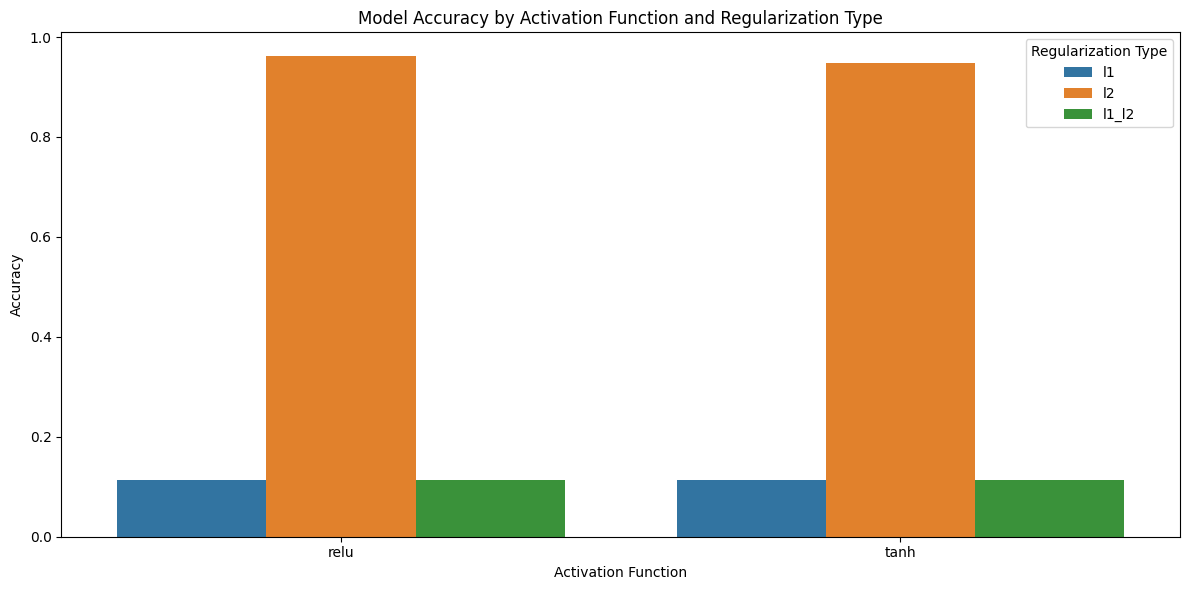

In [ ]:
def build_spec():
    deep_neurons = {
        1: 128,
        2: 256,
        3: 512,
        4: 256,
        5: 128,
        6: 64,
        7: 32,
    }

    grid = [
        ('relu', None),
        ('relu', 'l1'),
        ('relu', 'l2'),
        ('relu', 'l1_l2'),
        ('tanh', None),
        ('tanh', 'l1'),
        ('tanh', 'l2'),
        ('tanh', 'l1_l2'),
    ]

    specs = []
    for activation, reg_type in grid:
        specs.append({
            'label': f"ANN: activation={activation}, reg_type={reg_type}",
            'kwargs': {
                'input_shape': (28 * 28,),
                'hidden_activation': activation,
                'learning_rate': 0.001,
                'reg_type': reg_type,
                'regularization': 0.01,
                'epochs': 100,
                'batch_size': 128,
                'n_hidden': 7,
                'n_hidden_neurons': deep_neurons,
            },
        })

    return specs


def train_spec(spec, device_name: str = None):
    if device_name and tf.config.list_physical_devices('GPU'):
        with tf.device(device_name):
            model = Model(**spec['kwargs'])
    else:
        model = Model(**spec['kwargs'])

    model.train_model(X_train, Y_train, X_val, Y_val, device_name=device_name)
    loss, accuracy = model.model.evaluate(X_test, Y_test, verbose=0)
    return {
        'label': spec['label'],
        'model_type': 'ANN',
        'hidden_activation': spec['kwargs'].get('hidden_activation', 'NA'),
        'reg_type': spec['kwargs'].get('reg_type', 'NA'),
        'loss': loss,
        'accuracy': accuracy,
        'model': model,
    }

print("Training Device:", tf.config.list_physical_devices('GPU'))

specsheet = build_spec()
results = []

for start_index in range(0, len(specsheet)):
    batch_specs = specsheet[start_index:start_index + 1]
    with ThreadPoolExecutor(max_workers=1) as executor:
        futures = [
            executor.submit(train_spec, spec, device_name='/GPU:0') for spec in batch_specs
        ]
        for future in futures:
            results.append(future.result())

results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != 'model'} for result in results
])
results_df['reg_type'] = results_df['reg_type'].map(lambda x: 'None' if x is None else str(x))

display(results_df.sort_values(["hidden_activation", "accuracy"], ascending=[True, False]).reset_index(drop=True))

plt.figure(figsize=(12, 6))
sns.barplot(x='hidden_activation', y='accuracy', hue='reg_type', data=results_df)
plt.title('Model Accuracy by Activation Function and Regularization Type')
plt.xlabel('Activation Function')
plt.ylabel('Accuracy')
plt.legend(title='Regularization Type')
plt.tight_layout()
plt.show()

,label,model_type,hidden_activation,reg_type,loss,accuracy
0,"ANN: activation=relu, reg_type=None",ANN,relu,None,0.108834,0.9690
1,"ANN: activation=relu, reg_type=l2",ANN,relu,l2,0.448037,0.9614
2,"ANN: activation=relu, reg_type=l1",ANN,relu,l1,2.846495,0.1135
3,"ANN: activation=relu, reg_type=l1_l2",ANN,relu,l1_l2,2.834905,0.1135
4,"ANN: activation=tanh, reg_type=None",ANN,tanh,None,0.099556,0.9728
5,"ANN: activation=tanh, reg_type=l2",ANN,tanh,l2,0.504207,0.9488
6,"ANN: activation=tanh, reg_type=l1",ANN,tanh,l1,2.848876,0.1135
7,"ANN: activation=tanh, reg_type=l1_l2",ANN,tanh,l1_l2,2.837695,0.1135


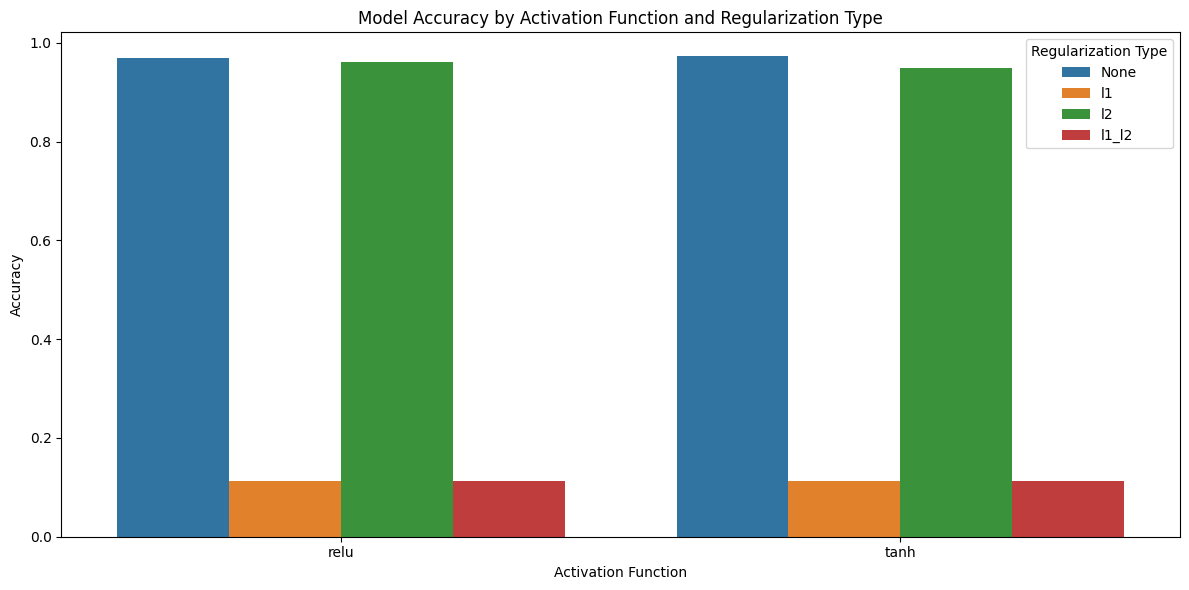

In [14]:
results_df = pd.DataFrame([
    {key: value for key, value in result.items() if key != 'model'} for result in results
])
results_df['reg_type'] = results_df['reg_type'].map(lambda x: 'None' if x is None else str(x))

display(results_df.sort_values(["hidden_activation", "accuracy"], ascending=[True, False]).reset_index(drop=True))

plt.figure(figsize=(12, 6))
sns.barplot(x='hidden_activation', y='accuracy', hue='reg_type', data=results_df)
plt.title('Model Accuracy by Activation Function and Regularization Type')
plt.xlabel('Activation Function')
plt.ylabel('Accuracy')
plt.legend(title='Regularization Type')
plt.tight_layout()
plt.show()